## SECTION 1: IMPORTS

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pricing_engine.bs import bs_call_price, bs_put_price
import pricing_engine.greeks as greeks
import pricing_engine.implied_vol as implied_vol
from pricing_engine.monte_carlo import asian_option_mc_price
from pricing_engine.trees import binomial_prices

## SECTION 2: SET THE PARAMETERS

Base scenario used throughout the notebook

In [2]:
#Spot price
S=100
#Strike price
K=100
#Interest rate
r=0.05
#Dividend rate
q=0.0
#Volatility
sigma=0.2
#Time to maturity
T=1.0

## SECTION 3: BLACK-SCHOLES PRICING

In [3]:
#Call price using BS formula
call_price = bs_call_price(S, K, r, sigma, T, q)
print(call_price)

10.450583572185565


In [4]:
#Put price using BS formula
put_price = bs_put_price(S, K, r, sigma, T, q)
print(put_price)

5.573526022256971


## SECTION 4: PUT-CALL PARITY

In [5]:
#Call-put difference
call_put_difference = call_price - put_price
print(call_put_difference)

4.877057549928594


In [6]:
#Actualised forward payoff
forward_payoff = S * math.exp(-q*T) - K * math.exp(-r*T)
print(forward_payoff)

4.877057549928594


In [7]:
#Absolute difference between the call_put_difference and forward payoff
print(abs(call_put_difference - forward_payoff))

0.0


## SECTION 5: GREEKS TABLE

In [8]:
call_greeks = pd.DataFrame({
        "Call": [
            greeks.delta_call(S, K, r, sigma, T, q),
            greeks.calculate_gamma(S, K, r, sigma, T, q),
            greeks.calculate_vega(S, K, r, sigma, T, q),
            greeks.calculate_rho_call(S, K, r, sigma, T, q),
            greeks.calculate_theta_call(S, K, r, sigma, T, q)
        ], 
        "Put":[   
            greeks.delta_put(S, K, r, sigma, T, q),
            greeks.calculate_gamma(S, K, r, sigma, T, q),
            greeks.calculate_vega(S, K, r, sigma, T, q),
            greeks.calculate_rho_put(S, K, r, sigma, T, q),
            greeks.calculate_theta_put(S, K, r, sigma, T, q)
        ]
    
    }, 
    index=["Delta", "Gamma", "Vega", "Rho", "Theta"]
)
display(call_greeks)

,Call,Put
Delta,0.636831,-0.363169
Gamma,0.018762,0.018762
Vega,37.524035,37.524035
Rho,53.232482,-41.890461
Theta,-6.414028,-1.657880


## SECTION 6: IMPLIED VOLATILITY

In [9]:
#Real sigma that is expected from the implied volatility formula
sigma_true = 0.2
#Call price with the BS formula
BS_call_price = bs_call_price(S, K, r, sigma_true, T)
#Implied volatility
implied_volatility = implied_vol.implied_volatility(BS_call_price, "C", S, K, r, T)
print(f"True sigma: {sigma_true}")
print(f"Implied sigma: {implied_volatility}")
print(f"Difference: {abs(sigma_true - implied_volatility)}")

True sigma: 0.2
Implied sigma: 0.19999999999999998
Difference: 2.7755575615628914e-17


## SECTION 7: BINOMIAL CONVERGENCE

In [10]:
steps = [10, 25, 50, 100, 250, 500, 1000]
bin_prices = [
        binomial_prices(S, K, r, sigma, T, "C", steps=10),
        binomial_prices(S, K, r, sigma, T, "C", steps=25),
        binomial_prices(S, K, r, sigma, T, "C", steps=50),
        binomial_prices(S, K, r, sigma, T, "C", steps=100),
        binomial_prices(S, K, r, sigma, T, "C", steps=250),
        binomial_prices(S, K, r, sigma, T, "C", steps=500),
        binomial_prices(S, K, r, sigma, T, "C", steps=1000)
    ]
BS_prices = [bs_call_price(S, K, r, sigma, T)] * 7

absolute_error = []

for i in range(0, len(bin_prices)):
    absolute_err = abs(bin_prices[i] - BS_prices[i])
    absolute_error.append(absolute_err)
    
convergence = pd.DataFrame({
    "Steps": steps,
    "Binomial price":bin_prices,
    "BS price":BS_prices,
    "Absolute error": absolute_error
})

display(convergence)

,Steps,Binomial price,BS price,Absolute error
0,10,10.253409,10.450584,0.197175
1,25,10.520966,10.450584,0.070382
2,50,10.410692,10.450584,0.039892
3,100,10.430612,10.450584,0.019972
4,250,10.442589,10.450584,0.007995
5,500,10.446585,10.450584,0.003998
6,1000,10.448584,10.450584,0.001999


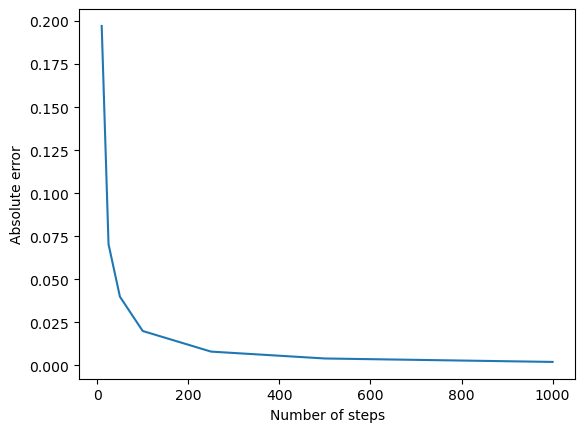

In [11]:
x = convergence["Steps"]
y = convergence["Absolute error"]
plt.plot(x, y)
plt.xlabel("Number of steps")
plt.ylabel("Absolute error")
plt.show()

## SECTION 8: AMERICAN VS EUROPEAN

**Comparison between European and American call without dividends**

In [12]:
#European call price without dividends
EU_call = binomial_prices(S, K, r, sigma, T, "C", exercise="european", q=0, steps=100)
#American call price without dividends 
US_call = binomial_prices(S, K, r, sigma, T, "C", exercise="american", q=0, steps=100)
#Price difference between european and american call without dividends
print(f"Absolute difference between European and American call without dividends {abs(EU_call - US_call)}")

Absolute difference between European and American call without dividends 0.0


In [13]:
#European call price without dividends
EU_call_dividends = binomial_prices(S, K, r, sigma, T, "C", exercise="european", q=0.05, steps=100)
#American call price without dividends 
US_call_dividends = binomial_prices(S, K, r, sigma, T, "C", exercise="american", q=0.05, steps=100)
#Price difference between european and american call without dividends
print(f"Absolute difference between European and American call with dividends {abs(EU_call_dividends - US_call_dividends)}")

Absolute difference between European and American call with dividends 0.08845122425184826


**Comparisons of European and American put in the money**

In [14]:
#European put in the money
EU_put_ITM = binomial_prices(80, K, r, sigma, T, "P", exercise="european", q=0, steps=100)
#American put in the money 
US_put_ITM = binomial_prices(80, K, r, sigma, T, "P", exercise="american", q=0, steps=100)
#Price difference between european and american put without dividends in the money
print(f"Absolute difference between European and American put without dividends {abs(EU_put_ITM - US_put_ITM)}")

Absolute difference between European and American put without dividends 3.0140293311728286


## SECTION 9: MONTE CARLO ASIAN OPTION

In [15]:
#Monte Carlo Asian Option with details
asian_option_detail = asian_option_mc_price(S, K, r, sigma, T, "C", q, n_paths=10000, n_steps=252, seed=42, return_detail=True)
display(pd.DataFrame.from_dict(asian_option_detail, orient="index", columns=["Value"]))

,Value
price,5.817900
standard_error,0.080748
ci_lower,5.659635
ci_upper,5.976166
n_paths,10000.000000
n_steps,252.000000


## SECTION 10: MONTE CARLO CONVERGENCE

In [16]:
n_paths=[1000, 5000, 10000, 50000, 100000]
asian_prices = {
    "n_paths":[],
    "Price":[],
    "Standard error": [],
    "Ci lower": [],
    "Ci upper": []
}

for path in n_paths:
    price = asian_option_mc_price(S, K, r, sigma, T, "C", q, n_paths=path, n_steps=252, seed=42, return_detail=True)
    asian_prices["Price"].append(price["price"])
    asian_prices["n_paths"].append(price["n_paths"])
    asian_prices["Standard error"].append(price["standard_error"])
    asian_prices["Ci lower"].append(price["ci_lower"])
    asian_prices["Ci upper"].append(price["ci_upper"])

df = pd.DataFrame(asian_prices)
df = df.set_index("n_paths")

display(df)

,Price,Standard error,Ci lower,Ci upper
n_paths,,,,
1000,6.005979,0.268002,5.480696,6.531263
5000,5.722236,0.114097,5.498605,5.945866
10000,5.817900,0.080748,5.659635,5.976166
50000,5.773978,0.035753,5.703902,5.844055
100000,5.793191,0.025408,5.743393,5.842990


## SECTION 11: ASIAN CALL VS EUROPEAN CALL

In [17]:
EU_bs_call = bs_call_price(S, K, r, sigma, T)
asian_mc_call = asian_option_mc_price(S, K, r, sigma, T, "C", q, n_paths=10000, n_steps=252, seed=42, return_detail=False)
print(f"European BS call price: {EU_bs_call}\nAsian Monte Carlo call price: {asian_mc_call}")

European BS call price: 10.450583572185565
Asian Monte Carlo call price: 5.817900470500514
